In [1]:
import numpy as np
from cnn.layers import Layer, Conv, BatchNorm, ReLU, Pooling, Flatten, Dense, Softmax
from cnn.neuralnet import NeuralNet
from cnn.optimizer import Optimizer
from cnn.results import Results
import time

In [2]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
data_dir = "../cifar-10-batches-py"

X_train = []
y_train = []

for i in range(1, 6):
    batch = unpickle(f"{data_dir}/data_batch_{i}")
    X_train.append(batch[b"data"])
    y_train.append(batch[b"labels"])

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train)

test_batch = unpickle(f"{data_dir}/test_batch")

X_test = test_batch[b"data"]
y_test = np.array(test_batch[b"labels"])

X_train = X_train.reshape(-1, 3, 32, 32)
X_test = X_test.reshape(-1, 3, 32, 32)

X_train_norm = X_train / 255
X_test_norm = X_test / 255

X_train_norm = X_train_norm.astype(np.float32)
X_test_norm = X_test_norm.astype(np.float32)


print(X_train_norm.shape)
print(X_test_norm.shape)
print(y_train.shape)
print(y_test.shape)

(50000, 3, 32, 32)
(10000, 3, 32, 32)
(50000,)
(10000,)


In [4]:
NN_1 = NeuralNet()
NN_1.layers = [Conv(32, 3, 3, 3, 1, 1), BatchNorm(32, 4), ReLU(), Conv(32, 32, 3, 3, 1, 1), BatchNorm(32, 4), ReLU(), Pooling(2, 2, 2), Conv(64, 32, 3, 3, 1, 1), BatchNorm(64, 4), ReLU(), Conv(64, 64, 3, 3, 1, 1), 
             BatchNorm(64, 4), ReLU(), Pooling(2, 2, 2), Conv(128, 64, 3, 3, 1, 1), BatchNorm(128, 4), ReLU(), Pooling(2, 2, 2), Flatten(), Dense(2048, 256), BatchNorm(256, 2), ReLU(), Dense(256, 10), Softmax()]

alpha = 0.001


In [5]:
X_batch = X_train_norm[:1]
y_batch = y_train[:1]

#Forward
start = time.perf_counter()

A_batch = NN_1.forward(X_batch)

forward_time = time.perf_counter() - start


#Backward
start = time.perf_counter()

NN_1.backward(A_batch, y_batch)

backward_time = time.perf_counter() - start


#Update
start = time.perf_counter()

NN_1.update(alpha, 1)

update_time = time.perf_counter() - start


print(f"Forward: {forward_time} seconds")
print(f"Backward: {backward_time} seconds")
print(f"Update: {update_time} seconds")

total = forward_time + backward_time + update_time

print(f"Total: {total} seconds")
#print(f"Estimated epoch: {total * (len(X_train) / 1) / 60} minutes")

Forward: 0.08475990011356771 seconds
Backward: 0.0942014001775533 seconds
Update: 0.017962399870157242 seconds
Total: 0.19692370016127825 seconds


In [6]:
NN_2 = NeuralNet()
NN_2.layers = [Conv(32, 3, 3, 3, 1, 1), BatchNorm(32, 4), ReLU(), Conv(32, 32, 3, 3, 1, 1), BatchNorm(32, 4), ReLU(), Pooling(2, 2, 2), Conv(64, 32, 3, 3, 1, 1), BatchNorm(64, 4), ReLU(), Conv(64, 64, 3, 3, 1, 1), 
             BatchNorm(64, 4), ReLU(), Pooling(2, 2, 2), Conv(128, 64, 3, 3, 1, 1), BatchNorm(128, 4), ReLU(), Pooling(2, 2, 2), Flatten(), Dense(2048, 256), BatchNorm(256, 2), ReLU(), Dense(256, 10), Softmax()]

optimizer = Optimizer()
epochs = 100
batch_size = 10
X_tiny = X_train_norm[:10]
y_tiny = y_train[:10]
cost_history = optimizer.adams_optimization(epochs, alpha, batch_size, NN_2, X_tiny, y_tiny)

Average Cost (Epoch 0) : 3.251598358154297
Average Cost (Epoch 1) : 0.10431183874607086
Average Cost (Epoch 2) : 0.020090969279408455
Average Cost (Epoch 3) : 0.011645788326859474
Average Cost (Epoch 4) : 0.008870641700923443
Average Cost (Epoch 5) : 0.007405465934425592
Average Cost (Epoch 6) : 0.006515989545732737
Average Cost (Epoch 7) : 0.00587885407730937
Average Cost (Epoch 8) : 0.005361787509173155
Average Cost (Epoch 9) : 0.004906023386865854
Average Cost (Epoch 10) : 0.004505622666329145
Average Cost (Epoch 11) : 0.004150013439357281
Average Cost (Epoch 12) : 0.0038307667709887028
Average Cost (Epoch 13) : 0.0035453173331916332
Average Cost (Epoch 14) : 0.0032905596308410168
Average Cost (Epoch 15) : 0.003059767186641693
Average Cost (Epoch 16) : 0.0028500817716121674
Average Cost (Epoch 17) : 0.0026604686863720417
Average Cost (Epoch 18) : 0.002489466452971101
Average Cost (Epoch 19) : 0.00233663571998477
Average Cost (Epoch 20) : 0.00219969660975039
Average Cost (Epoch 21) :

In [7]:
results = Results()
A_tiny = NN_2.forward(X_tiny)
acc = results.accuracy(A_tiny, y_tiny)
print(f"Accuracy : {acc}%")

Accuracy : 100.0%


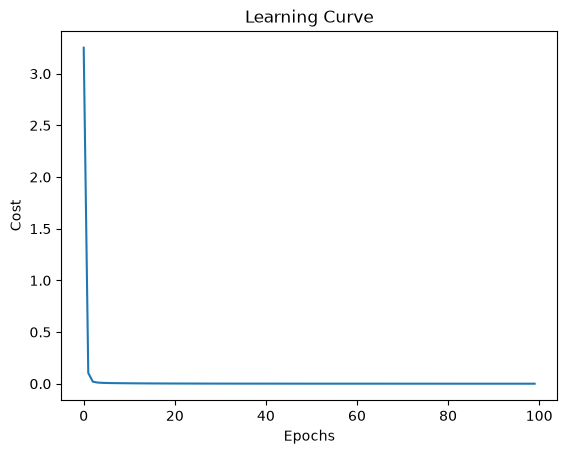

In [8]:
results.learning_curve(cost_history)